1. Обработка данных

Здесь я работаю в джупиторе

In [ ]:
import os
import json
import re
import html

input_directories = ["updated_instructions", "updated_ocr_instructions"]
output_directory = "cleaned_instructions"
os.makedirs(output_directory, exist_ok=True)

total_files = 0
processed_files_per_dir = {directory: 0 for directory in input_directories}

def clean_text(text):
    text = html.unescape(text)
    text = re.sub(r"^\d+[,.\s]+", "", text, flags=re.MULTILINE)
    text = text.replace(" O ", " 0 ").replace(" I ", " 1 ")
    text = re.sub(r"(\S)\n(\S)", r"\1 \2", text)
    text = re.sub(r"^\d+\s+", "", text, flags=re.MULTILINE)
    text = re.sub(r"\n+", " ", text).strip()
    text = re.sub(r"\s+", " ", text).strip()
    text = re.sub(r"[^а-яА-Яa-zA-Z0-9.,!?;:()\"'\-–—\s]", "", text)
    text = re.sub(r"[–—−]", "-", text)
    text = re.sub(r"\b\w\b", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

# делаю единую структуру json-файлов, чтобы у всех был ключ 'text'
for input_directory in input_directories:
    if not os.path.exists(input_directory):
        print(f"Директория {input_directory} не найдена")
        continue

    for json_file in os.listdir(input_directory):
        if json_file.endswith(".json"):
            json_path = os.path.join(input_directory, json_file)

            with open(json_path, "r", encoding="utf-8") as f:
                parsed_data = json.load(f)

            if "text_sections" in parsed_data:
                sections_key = "text_sections"
                content_key = "content"
            elif "ocr_text_sections" in parsed_data:
                sections_key = "ocr_text_sections"
                content_key = "text"
            else:
                print(f"Файл {json_file} не содержит текстовых данных")
                continue

            text_content = clean_text(" ".join(
                section.get(content_key, "").strip()
                for section in parsed_data.get(sections_key, [])
                if section.get(content_key)
            ))

            updated_data = {
                "mnn": parsed_data["mnn"],
                "trade_name": parsed_data["trade_name"],
                "drug_id": parsed_data["drug_id"],
                "file_name": parsed_data["file_name"],
                "text": text_content
            }

            output_path = os.path.join(output_directory, json_file)
            with open(output_path, "w", encoding="utf-8") as f:
                json.dump(updated_data, f, ensure_ascii=False, indent=4)

            print(f"Обновлён файл: {json_file} из {input_directory}")

            total_files += 1
            processed_files_per_dir[input_directory] += 1


for directory, count in processed_files_per_dir.items():
    print(f"{directory}: {count} файлов обработано")
print(f"Всего файлов: {total_files}")

Обновлён файл: 005ae4c2-e9e2-4ad1-a2f7-001b794ec8d6.json из updated_instructions
Обновлён файл: 008bef68-b54b-4705-9c0c-2209899b6e90.json из updated_instructions
Обновлён файл: 026f142c-5b7e-4275-bb05-8439a9a7c92a.json из updated_instructions
Обновлён файл: 033ccbd2-1d45-4563-8802-6233ab9b8896.json из updated_instructions
Обновлён файл: 0407b4f2-4b96-4cb4-8d2b-ed0e227e7da1.json из updated_instructions
Обновлён файл: 05826418-0641-4f00-a538-fd25ff10127e.json из updated_instructions
Обновлён файл: 058b4a4e-05a8-40f6-9b59-9e06c6aa4691.json из updated_instructions
Обновлён файл: 05942353-d2c6-47ba-9559-faca8cee6cc3.json из updated_instructions
Обновлён файл: 064991b7-cc85-48ac-9c2c-52cd5cdc873f.json из updated_instructions
Обновлён файл: 075e07d1-cb0c-493e-9bcd-ffc5177a0ae2.json из updated_instructions
Обновлён файл: 08024694-409e-45d8-a0e5-c265c2ce9b7b.json из updated_instructions
Обновлён файл: 08747b75-9399-42c8-a21b-1ec35e1b836c.json из updated_instructions
Обновлён файл: 089d004d-a376

Обновлён файл: 74d2237b-6339-4cae-b37a-35665ba1710a.json из updated_instructions
Обновлён файл: 7517515e-aa2c-435f-9ec3-332919e4945e.json из updated_instructions
Обновлён файл: 7580803c-97b9-4905-95c3-18feb3318f4b.json из updated_instructions
Обновлён файл: 77e6c4bf-cdeb-43f3-a691-70282291c802.json из updated_instructions
Обновлён файл: 7a3c3ee9-d1ab-4dbf-967a-6ce3c76d9181.json из updated_instructions
Обновлён файл: 7a7da85c-1964-48e5-b804-b11eb771dda3.json из updated_instructions
Обновлён файл: 7bddce3d-2673-46ef-9b99-579cc9e8fe08.json из updated_instructions
Обновлён файл: 7bfdce68-c730-4d69-8613-b53dacb364c3.json из updated_instructions
Обновлён файл: 7db30ae8-5c62-475c-be71-b59098642009.json из updated_instructions
Обновлён файл: 7de889de-6b82-47a4-b4f9-f45b70f5864c.json из updated_instructions
Обновлён файл: 800a725a-5f5c-4763-be91-1b43c1b0f4ff.json из updated_instructions
Обновлён файл: 8012d5e6-594d-48dd-8ebd-0fd91ad879b7.json из updated_instructions
Обновлён файл: 8022f635-faa9

Обновлён файл: 00b77306-6d48-4803-8f4d-e3f7962b9a18.json из updated_ocr_instructions
Обновлён файл: 01042076-dc5c-48e5-bf7c-2c4fc88202b0.json из updated_ocr_instructions
Обновлён файл: 013b6b61-28a5-44da-8ac4-6eb49145139c.json из updated_ocr_instructions
Обновлён файл: 026c21c8-8957-43e4-b721-d69996fc8267.json из updated_ocr_instructions
Обновлён файл: 026f86ab-6a65-4ce2-bcee-0f8285b64024.json из updated_ocr_instructions
Обновлён файл: 043a3b0b-63af-4ca7-9a0b-64c99e9e93fa.json из updated_ocr_instructions
Обновлён файл: 052f5bb4-8023-4ae4-b7fe-665586b10796.json из updated_ocr_instructions
Обновлён файл: 06a7881a-0e7e-45c2-9ec5-d8b07acc52ee.json из updated_ocr_instructions
Обновлён файл: 07e5eaa1-0497-4c57-849b-3807df007afd.json из updated_ocr_instructions
Обновлён файл: 080e26d9-9a34-4e9d-9fe4-a6f19a92af2b.json из updated_ocr_instructions
Обновлён файл: 0bdaa907-eba9-40a2-8558-00dd03ab21a5.json из updated_ocr_instructions
Обновлён файл: 0c0fb080-2b87-42d8-bd40-aa331c3bd4c4.json из updat

Обновлён файл: 5a1ebe55-1f7b-443e-a2f6-46d77bd08074.json из updated_ocr_instructions
Обновлён файл: 5bb94c01-70f7-4cc9-a15a-de1db23dfb28.json из updated_ocr_instructions
Обновлён файл: 5de92ab2-83cb-4ddd-b6bf-f8f1a664467a.json из updated_ocr_instructions
Обновлён файл: 5de9895c-a1e1-4398-b541-0795206c334f.json из updated_ocr_instructions
Обновлён файл: 5e8ea2fb-d3de-44d5-a949-465dced0b055.json из updated_ocr_instructions
Обновлён файл: 600b55cd-6386-4fe3-a31e-c9425adb8f08.json из updated_ocr_instructions
Обновлён файл: 6065efdc-9382-4492-acf1-1a4b3a2e60d6.json из updated_ocr_instructions
Обновлён файл: 61747448-2de5-4e05-a379-826ed7b340d3.json из updated_ocr_instructions
Обновлён файл: 62bf3811-3575-406b-9ce6-c642431e7e60.json из updated_ocr_instructions
Обновлён файл: 631adecd-ff8a-4026-888f-22eff81657a5.json из updated_ocr_instructions
Обновлён файл: 63f0bc3f-6216-4dd4-91c5-052e691e148e.json из updated_ocr_instructions
Обновлён файл: 64cc287c-e8d9-4cf4-a863-f3a3f6a390ac.json из updat

Обновлён файл: c345f407-1460-46da-b410-f7c259140a60.json из updated_ocr_instructions
Обновлён файл: c3c5e531-3df0-4523-9042-d36e02158935.json из updated_ocr_instructions
Обновлён файл: c3cf1d26-d055-418b-814e-4d90ad1e9587.json из updated_ocr_instructions
Обновлён файл: c4644183-c9f5-42e0-8f71-179c772d1f78.json из updated_ocr_instructions
Обновлён файл: c685e0a6-9207-428b-86a0-71e59caf7d9b.json из updated_ocr_instructions
Обновлён файл: c6a71699-819e-40a6-a9d3-1a383fa5021f.json из updated_ocr_instructions
Обновлён файл: c744b69d-d2b0-4774-a3d7-3f819adfa407.json из updated_ocr_instructions
Обновлён файл: c782f9df-f891-49af-808d-7cde7582422a.json из updated_ocr_instructions
Обновлён файл: c81f6359-272c-429a-9aa7-8c8b73d7db4f.json из updated_ocr_instructions
Обновлён файл: c8587a32-a02c-4228-9cd7-286650f34025.json из updated_ocr_instructions
Обновлён файл: c91a4cf7-3b84-467c-9b87-f97365e2b03a.json из updated_ocr_instructions
Обновлён файл: c96d6c5f-b598-4756-b7d4-e12da22b7611.json из updat

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Пользователь\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Пользователь\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Средняя длина текста (после лемматизации): 25347.94 символов
Средняя длина текста (после лемматизации): 2804.66 слов
Мин./Макс. длина текста: 584 / 73948 символов
Мин./Макс. количество слов: 70 / 8200


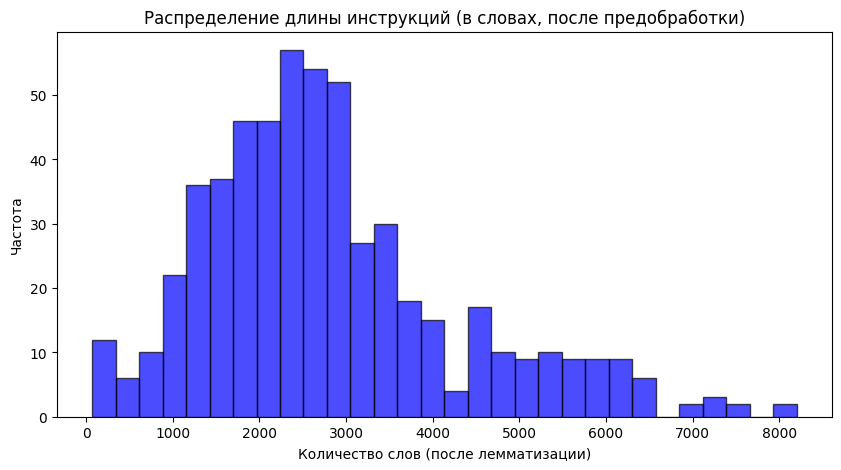

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import pymorphy2

input_directory = "cleaned_instructions"

nltk.download("stopwords")
nltk.download("punkt")
russian_stopwords = set(stopwords.words("russian"))
morph = pymorphy2.MorphAnalyzer()

def lemmatize_and_clean_text(text):
    text = html.unescape(text)  
    words = word_tokenize(text, language="russian")  
    lemmatized_words = [
        morph.parse(word)[0].normal_form
        for word in words if word.isalnum() and word.lower() not in russian_stopwords
    ]
    return " ".join(lemmatized_words)  

text_lengths = []
word_counts = []

for json_file in os.listdir(input_directory):
    if json_file.endswith(".json"):
        json_path = os.path.join(input_directory, json_file)

        with open(json_path, "r", encoding="utf-8") as f:
            parsed_data = json.load(f)

        raw_text = parsed_data.get("text", "").strip()
        if raw_text:
            processed_text = lemmatize_and_clean_text(raw_text)  
            text_lengths.append(len(processed_text))  
            word_counts.append(len(processed_text.split()))  

mean_length = np.mean(text_lengths)
mean_word_count = np.mean(word_counts)
min_length, max_length = np.min(text_lengths), np.max(text_lengths)
min_words, max_words = np.min(word_counts), np.max(word_counts)

print(f"Средняя длина текста (после лемматизации): {mean_length:.2f} символов")
print(f"Средняя длина текста (после лемматизации): {mean_word_count:.2f} слов")
print(f"Мин./Макс. длина текста: {min_length} / {max_length} символов")
print(f"Мин./Макс. количество слов: {min_words} / {max_words}")

plt.figure(figsize=(10,5))
plt.hist(word_counts, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.xlabel("Количество слов (после лемматизации)")
plt.ylabel("Частота")
plt.title("Распределение длины инструкций (в словах, после предобработки)")
plt.show()

In [ ]:
import textwrap

input_directory = "cleaned_instructions"
output_directory = "chunked_instructions"
os.makedirs(output_directory, exist_ok=True)

# размер чанка в словах (около 1024-2048 токенов)
CHUNK_SIZE_MIN = 900   # минимальный размер чанка (~1024 токена)
CHUNK_SIZE_MAX = 1800  # максимальный размер чанка (~2048 токенов)

def split_into_chunks(text, min_size=CHUNK_SIZE_MIN, max_size=CHUNK_SIZE_MAX):
    words = text.split()

    if len(words) <= max_size:
        return [text]

    chunks = []
    for i in range(0, len(words), max_size):
        chunk = " ".join(words[i:i+max_size])
        chunks.append(chunk)

    return chunks

total_files = 0
total_chunks = 0

for json_file in os.listdir(input_directory):
    if json_file.endswith(".json"):
        json_path = os.path.join(input_directory, json_file)

        with open(json_path, "r", encoding="utf-8") as f:
            parsed_data = json.load(f)

        text = parsed_data.get("text", "").strip()
        if text:
            chunks = split_into_chunks(text)

            for i, chunk in enumerate(chunks):
                chunked_data = {
                    "mnn": parsed_data["mnn"],
                    "trade_name": parsed_data["trade_name"],
                    "drug_id": parsed_data["drug_id"],
                    "file_name": parsed_data["file_name"],
                    "chunk_id": f"{json_file.replace('.json', '')}_chunk_{i+1}",
                    "text": chunk
                }

                chunked_file = os.path.join(output_directory, f"{json_file.replace('.json', '')}_chunk_{i+1}.json")
                with open(chunked_file, "w", encoding="utf-8") as f:
                    json.dump(chunked_data, f, ensure_ascii=False, indent=4)

                total_chunks += 1

        total_files += 1
        print(f"Обработан файл: {json_file}, создано чанков: {len(chunks)}")

print(f"\nВсего обработано файлов: {total_files}")
print(f"Всего создано чанков: {total_chunks}")

Обработан файл: 005ae4c2-e9e2-4ad1-a2f7-001b794ec8d6.json, создано чанков: 3
Обработан файл: 008bef68-b54b-4705-9c0c-2209899b6e90.json, создано чанков: 2
Обработан файл: 00b77306-6d48-4803-8f4d-e3f7962b9a18.json, создано чанков: 3
Обработан файл: 01042076-dc5c-48e5-bf7c-2c4fc88202b0.json, создано чанков: 2
Обработан файл: 013b6b61-28a5-44da-8ac4-6eb49145139c.json, создано чанков: 2
Обработан файл: 026c21c8-8957-43e4-b721-d69996fc8267.json, создано чанков: 1
Обработан файл: 026f142c-5b7e-4275-bb05-8439a9a7c92a.json, создано чанков: 2
Обработан файл: 026f86ab-6a65-4ce2-bcee-0f8285b64024.json, создано чанков: 1
Обработан файл: 033ccbd2-1d45-4563-8802-6233ab9b8896.json, создано чанков: 2
Обработан файл: 0407b4f2-4b96-4cb4-8d2b-ed0e227e7da1.json, создано чанков: 2
Обработан файл: 043a3b0b-63af-4ca7-9a0b-64c99e9e93fa.json, создано чанков: 3
Обработан файл: 052f5bb4-8023-4ae4-b7fe-665586b10796.json, создано чанков: 2
Обработан файл: 05826418-0641-4f00-a538-fd25ff10127e.json, создано чанков: 3

Обработан файл: 526ec577-5e3c-494b-9315-2ff27f0b30bc.json, создано чанков: 2
Обработан файл: 5325e6d9-80ec-40b1-ac02-0117dc58141d.json, создано чанков: 6
Обработан файл: 536f4f8b-f2f4-48cf-8e29-a733e166c2a5.json, создано чанков: 3
Обработан файл: 5433c43f-5f9a-41a5-b9e2-8ab737cbca65.json, создано чанков: 3
Обработан файл: 5473b3c5-a3b8-4b2d-93a7-eaece6885966.json, создано чанков: 2
Обработан файл: 54b85678-64b7-43ce-a27d-2d366d8d47e8.json, создано чанков: 1
Обработан файл: 5555a480-cfcb-4f16-8347-5f95bf8acc9c.json, создано чанков: 2
Обработан файл: 5563ede4-6ca2-416e-95e1-45d130831338.json, создано чанков: 2
Обработан файл: 55831901-4dd2-4d41-832d-427d7afa80f9.json, создано чанков: 4
Обработан файл: 56352471-1fe2-4e83-971f-49f022fe2587.json, создано чанков: 2
Обработан файл: 56ab79c5-6bd8-44a0-beec-5fa5382de5eb.json, создано чанков: 3
Обработан файл: 5712b48f-0395-4292-bab3-e954df40d262.json, создано чанков: 2
Обработан файл: 57bc0ff3-b8d3-4d69-b4c9-a98e12036376.json, создано чанков: 2

Обработан файл: a013e24b-627c-446b-b783-02860664ffca.json, создано чанков: 2
Обработан файл: a0d82047-92a4-42b9-9201-25af94ff07c8.json, создано чанков: 2
Обработан файл: a131a452-9ca0-4830-92e1-811e372cab87.json, создано чанков: 4
Обработан файл: a2041173-e7d7-48d2-86af-74b8471cfaef.json, создано чанков: 5
Обработан файл: a214a173-13c7-4b79-8da4-a69affeabc05.json, создано чанков: 4
Обработан файл: a38da3f7-2963-4405-9b4d-9d6fb8c7a015.json, создано чанков: 2
Обработан файл: a49c2b23-5b05-4260-8def-9b700227d1a3.json, создано чанков: 2
Обработан файл: a4fae48d-4823-4e50-8ab0-38f0a86d030e.json, создано чанков: 2
Обработан файл: a55c56ba-76d0-4283-a059-7fced76f7768.json, создано чанков: 2
Обработан файл: a5dd3a93-88fc-49bb-b216-ae5f6054e018.json, создано чанков: 2
Обработан файл: a614f366-4a9a-42d5-b807-ef35960a552e.json, создано чанков: 2
Обработан файл: a9494a58-9133-450c-b578-76064583edd5.json, создано чанков: 2
Обработан файл: a967d2ef-a0f1-4371-b71d-0c86e79df628.json, создано чанков: 2

Обработан файл: f646a039-bfd9-45bd-95ae-3f54cda798aa.json, создано чанков: 3
Обработан файл: f659a127-a4c1-4d13-bce0-f76b0670814c.json, создано чанков: 2
Обработан файл: f6ff49ee-5080-436b-b940-50baef0c17d6.json, создано чанков: 3
Обработан файл: f881b79b-7bb4-4140-ba9e-ae1f8171519b.json, создано чанков: 2
Обработан файл: f8c9a86a-ddfe-41c4-8816-34f74a5fbedb.json, создано чанков: 2
Обработан файл: f99c3b40-9d8f-4220-80f7-49479c45beca.json, создано чанков: 2
Обработан файл: f9e1b77c-e651-4919-8d93-46b9a6ccd21d.json, создано чанков: 2
Обработан файл: f9f2369c-54dd-4903-bed3-b8444d5524f4.json, создано чанков: 3
Обработан файл: f9f887a4-ba26-4cd4-b385-0c34453fc521.json, создано чанков: 1
Обработан файл: fa577194-c694-4cff-bfde-0e0f13761415.json, создано чанков: 2
Обработан файл: fafcfdbd-581d-4f2b-aacb-de10ce33a835.json, создано чанков: 3
Обработан файл: fc33bc24-0310-4774-8bfd-4af1bd43385c.json, создано чанков: 3
Обработан файл: fc8e9328-1ec6-4c2b-89ee-fbc2a7ed6fa6.json, создано чанков: 2

2. Эмбеддинги 

На этом этапе я перешла в гугл коллаб. Был взят SentenceTransformers (all-MiniLM-L6-v2)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import time
import torch
from tqdm import tqdm
from sentence_transformers import SentenceTransformer

input_directory = "/content/drive/MyDrive/Colab Notebooks/chunked_instructions"
output_directory = "/content/drive/MyDrive/Colab Notebooks/embeddings"

os.makedirs(output_directory, exist_ok=True)

embedding_file = os.path.join(output_directory, "sentence_transformers_embeddings.npy")
metadata_file = os.path.join(output_directory, "sentence_transformers_metadata.json")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2").to(device)

if os.path.exists(embedding_file) and os.path.exists(metadata_file):
    print("Эмбеддинги уже существуют. Загружаем...")
    embeddings = np.load(embedding_file)
    with open(metadata_file, "r", encoding="utf-8") as f:
        metadata = json.load(f)
else:
    embeddings = []
    metadata = []
    start_time = time.time()

    json_files = [f for f in os.listdir(input_directory) if f.endswith(".json")]
    total_files = len(json_files)

    texts = []
    metadata_list = []

    for json_file in tqdm(json_files, desc="Обработка чанков"):
        json_path = os.path.join(input_directory, json_file)

        with open(json_path, "r", encoding="utf-8") as f:
            chunk_data = json.load(f)

        text = chunk_data["text"]
        chunk_id = chunk_data["chunk_id"]

        texts.append(text)
        metadata_list.append({
            "chunk_id": chunk_id,
            "mnn": chunk_data["mnn"],
            "trade_name": chunk_data["trade_name"],
            "drug_id": chunk_data["drug_id"],
            "file_name": chunk_data["file_name"]
        })

    batch_size = 32
    for i in tqdm(range(0, len(texts), batch_size), desc="Векторизация"):
        batch_texts = texts[i:i + batch_size]
        batch_embeddings = model.encode(batch_texts, convert_to_numpy=True, batch_size=batch_size, device=device)
        embeddings.extend(batch_embeddings)

    np.save(embedding_file, np.array(embeddings))
    with open(metadata_file, "w", encoding="utf-8") as f:
        json.dump(metadata_list, f, ensure_ascii=False, indent=4)

    total_time = time.time() - start_time
    print(f"\nВекторизация завершена за {total_time:.2f} секунд.")
    print(f"Всего векторизировано чанков: {len(embeddings)}")

cuda


Векторизация: 100%|██████████| 43/43 [00:34<00:00,  1.23it/s]



Векторизация завершена за 60.97 секунд.
Всего векторизировано чанков: 1347


Визуализация результатов

- TSNE

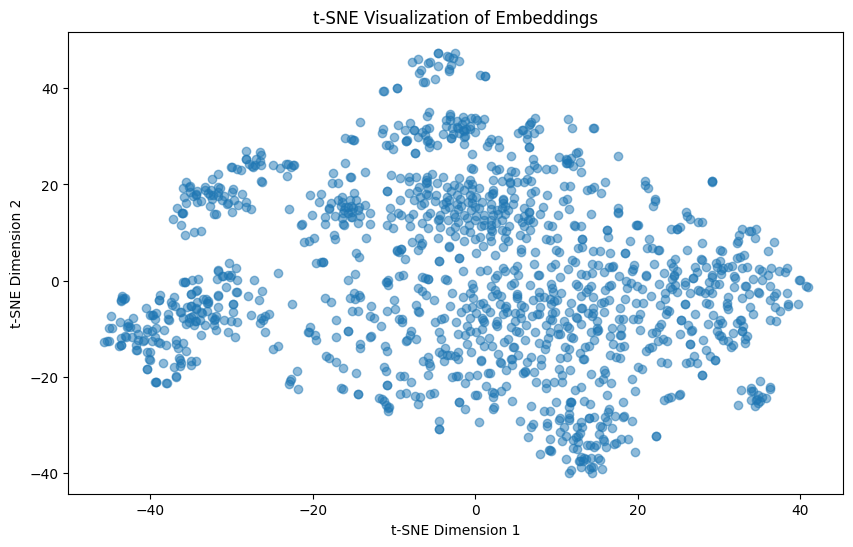

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

embedding_file = "/content/drive/MyDrive/Colab Notebooks/embeddings/sentence_transformers_embeddings.npy"

embeddings = np.load(embedding_file)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 6))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.5)
plt.title("t-SNE Visualization of Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()

- UMAP

In [11]:
!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 4.8 MB/s eta 0:00:00


Форма эмбеддингов: (1347, 384)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


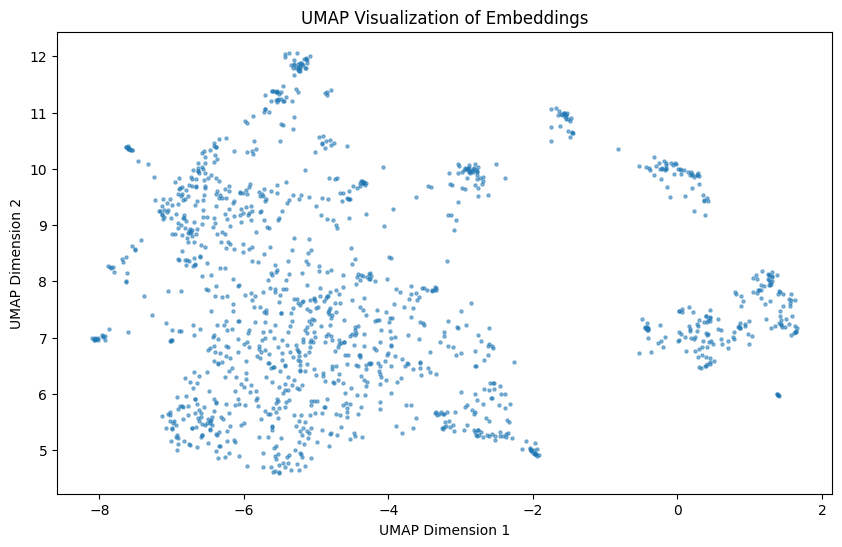

In [13]:
import umap

embedding_file = "/content/drive/MyDrive/Colab Notebooks/embeddings/sentence_transformers_embeddings.npy"

embeddings = np.load(embedding_file)

print(f"Форма эмбеддингов: {embeddings.shape}")

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embeddings_2d = reducer.fit_transform(embeddings)

plt.figure(figsize=(10, 6))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=5, alpha=0.5)
plt.title("UMAP Visualization of Embeddings")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.show()

3. Векторное хранилище - FAISS

In [18]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 30.5 MB/s eta 0:00:00


In [19]:
import faiss

embedding_file = "/content/drive/MyDrive/Colab Notebooks/embeddings/sentence_transformers_embeddings.npy"
metadata_file = "/content/drive/MyDrive/Colab Notebooks/embeddings/sentence_transformers_metadata.json"

embeddings = np.load(embedding_file)
with open(metadata_file, "r", encoding="utf-8") as f:
    metadata = json.load(f)

embedding_dim = embeddings.shape[1]

index = faiss.IndexFlatL2(embedding_dim)

index.add(embeddings)

def search_similar(query_embedding, top_k=5):
    distances, indices = index.search(query_embedding.reshape(1, -1), top_k)
    results = []
    for i, idx in enumerate(indices[0]):
        results.append({
            "rank": i + 1,
            "distance": distances[0][i],
            "chunk_id": metadata[idx]["chunk_id"],
            "file_name": metadata[idx]["file_name"],
            "trade_name": metadata[idx]["trade_name"],
            "mnn": metadata[idx]["mnn"]
        })
    return results

query_text = "Какие побочные эффекты могут возникнуть у пациента?"
query_embedding = model.encode(query_text, convert_to_numpy=True)

similar_chunks = search_similar(query_embedding, top_k=5)

for res in similar_chunks:
    print(f"Rank: {res['rank']}, Distance: {res['distance']:.4f}")
    print(f"Препарат: {res['trade_name']} ({res['mnn']})")
    print(f"Файл: {res['file_name']}, Чанк ID: {res['chunk_id']}")
    print("-" * 50)

Rank: 1, Distance: 0.9021
Препарат: Бендамустин (Бендамустин)
Файл: 3baf33a6-4020-4d89-91e6-fac72f9bd0fd.pdf, Чанк ID: 3baf33a6-4020-4d89-91e6-fac72f9bd0fd_chunk_3
--------------------------------------------------
Rank: 2, Distance: 0.9428
Препарат: Оксалиплатин Эбеве® (Оксалиплатин)
Файл: 3769e5af-03ea-4d7e-865e-572ebefb0df2.pdf, Чанк ID: 3769e5af-03ea-4d7e-865e-572ebefb0df2_chunk_3
--------------------------------------------------
Rank: 3, Distance: 0.9555
Препарат: Венклекста (Венетоклакс)
Файл: 5325e6d9-80ec-40b1-ac02-0117dc58141d.pdf, Чанк ID: 5325e6d9-80ec-40b1-ac02-0117dc58141d_chunk_6
--------------------------------------------------
Rank: 4, Distance: 0.9755
Препарат: КАРФИЛЗОМИБ-ПРОМОМЕД (Карфилзомиб)
Файл: 28e6ed01-7f00-4365-b008-2a7d8e582e61.pdf, Чанк ID: 28e6ed01-7f00-4365-b008-2a7d8e582e61_chunk_3
--------------------------------------------------
Rank: 5, Distance: 0.9819
Препарат: Цисплатин-РОНЦ® (Цисплатин)
Файл: 65e70e23-d229-4b0b-ae9e-45403bbe0aa7.pdf, Чанк ID: 65

4. Агенты

Запустила локально ламу, поэтому снова вернулась в джупитр

In [1]:
from langchain_community.llms import Ollama

mn_model = Ollama(base_url='http://localhost:11434', model="llama3.1")

Пайплан для RAG (который я позже изменю)

In [3]:
import faiss
import numpy as np
import json
from sentence_transformers import SentenceTransformer
import ollama

embedding_file = "sentence_transformers_embeddings.npy"
metadata_file = "sentence_transformers_metadata.json"

embeddings = np.load(embedding_file)
with open(metadata_file, "r", encoding="utf-8") as f:
    metadata = json.load(f)

embedding_dim = embeddings.shape[1]

index = faiss.IndexFlatL2(embedding_dim)
index.add(embeddings)

def search_similar(query_embedding, top_k=5):
    distances, indices = index.search(query_embedding.reshape(1, -1), top_k)
    results = []
    for i, idx in enumerate(indices[0]):
        results.append({
            "rank": i + 1,
            "distance": distances[0][i],
            "chunk_id": metadata[idx]["chunk_id"],
            "file_name": metadata[idx]["file_name"],
            "trade_name": metadata[idx]["trade_name"],
            "mnn": metadata[idx]["mnn"],
            "text": metadata[idx].get("text", "") 
        })
    return results


# проверяем работу

embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

query_text = "Какие побочные эффекты могут возникнуть у пациента?"
query_embedding = embedding_model.encode(query_text, convert_to_numpy=True)

similar_chunks = search_similar(query_embedding, top_k=5)


retrieved_text = "\n\n".join([f"Источник: {res['file_name']}\n{res['text']}" for res in similar_chunks])

prompt = f"""
Контекст:
Пациент спрашивает: "{query_text}"
Вот информация из инструкции к препарату:

{retrieved_text}

Ответь на вопрос пациента, основываясь только на предоставленном тексте. Если информации недостаточно, предложи пациенту обратиться к врачу.
"""

response = ollama.chat(model="llama3.1", messages=[{"role": "user", "content": prompt}])

print("Ответ Ollama:") # llama 3.1
print(response['message']['content']) 

Ответ Ollama:
К сожалению, в предоставленном тексте нет информации о побочных эффектах.


- Агент №1: задает вопросы

In [4]:
def generate_patient_question(mnn, trade_name):
    prompt = f"""
    Контекст:
    Пациент проходит курс лечения препаратом с международным непатентованным названием: "{mnn}", торговое название: "{trade_name}".
    Инструкция содержит текст с описанием показаний, противопоказаний, побочных эффектов и способа применения.

    Задача:
    **Сформулируй вопрос от лица пациента**, который пытается разобраться с указанной инструкцией.
    **Вопрос ДОЛЖЕН быть связан ТОЛЬКО с препаратом "{trade_name}" и его действующим веществом "{mnn}"**.
    **Не упоминай другие лекарства или их аналоги**.
    **Вопрос должен быть связан с инструкцией (например, дозировка, побочные эффекты, совместимость с другими препаратами)**.

    Пример верного вопроса:
    **"Каковы возможные побочные эффекты препарата {trade_name}?"**
    """

    try:
        response = ollama.chat(model="llama3.1", messages=[{"role": "user", "content": prompt}])

        if "message" in response and "content" in response["message"]:
            return response["message"]["content"]
        else:
            return "Ошибка: ответ от Ollama пустой или имеет неверный формат."

    except Exception as e:
        return f"Ошибка: {str(e)}"

Проверяем работу

In [5]:
mnn_example = "Цисплатин"
trade_name_example = "Цисплатин-РОНЦ®"
question = generate_patient_question(mnn_example, trade_name_example)

print("Вопрос пациента:", question)

Вопрос пациента: **"При каких заболеваниях необходимо применять препарат Цисплатин-РОНЦ®, а при каких противопоказаний следует воздержаться от его применения?"**.


In [6]:
mnn_example = "Эпирубицин"
trade_name_example = "Эпирубицин-РОНЦ®"
question = generate_patient_question(mnn_example, trade_name_example)
print("Вопрос пациента:", question)

Вопрос пациента: **Вопрос:**

"Могу ли я принимать препарат Эпирубицин-РОНЦ®, если у меня есть проблемы с кровотворением?"

(Использую ваш пример, аналогичный вопрос связан с "противопоказаниями" и приведен в инструкции по применению лекарственного средства.)


In [7]:
mnn_example = "Трипторелин"
trade_name_example = "Декапептил"
question = generate_patient_question(mnn_example, trade_name_example)
print("Вопрос пациента:", question)

Вопрос пациента: Сколько раз в неделю я должен принимать препарат "Декапептил"?


Здесь я поняла, что в sentence_transformers_metadata.json отсутствует text

In [ ]:
import os

metadata_file = "sentence_transformers_metadata.json"
cleaned_instructions_dir = "cleaned_instructions"
metadata_full_file = "sentence_transformers_metadata_full.json"

with open(metadata_file, "r", encoding="utf-8") as f:
    metadata = json.load(f)

instructions_texts = {}

for filename in os.listdir(cleaned_instructions_dir):
    if filename.endswith(".json"): 
        json_path = os.path.join(cleaned_instructions_dir, filename)
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        
        file_name_pdf = filename.replace(".json", ".pdf")
        instructions_texts[file_name_pdf] = data["text"]

for entry in metadata:
    file_name = entry["file_name"]
    if file_name in instructions_texts:
        entry["text"] = instructions_texts[file_name]
    else:
        entry["text"] = ""  

with open(metadata_full_file, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=4)

Агент №2: отвечает на вопросы

In [8]:
metadata_file = "sentence_transformers_metadata_full.json"

with open(metadata_file, "r", encoding="utf-8") as f:
    metadata = json.load(f)

def find_instruction(mnn_name):
    for entry in metadata:
        if entry["mnn"].lower() == mnn_name.lower():
            return entry["text"], entry["file_name"]
    return None, None

def generate_patient_answer(question, mnn_name):
    instruction_text, file_name = find_instruction(mnn_name)

    if not instruction_text:
        return "Извините, инструкция к этому препарату не найдена. Обратитесь к врачу."

    instruction_excerpt = instruction_text[:3000]  

    prompt = f"""
    Ты — медицинский консультант, отвечающий пациентам на основе официальных инструкций к препаратам.

    **Контекст:**
    Пользователь спрашивает: "{question}"
    
    **На основе предоставленного текста инструкции** (файл: {file_name}) **необходимо дать точный ответ на вопрос.**
    
    **Информация из инструкции:**
    {instruction_excerpt}

    **Требования к ответу:**
    - Дай четкий и краткий ответ на вопрос пациента, основываясь только на тексте инструкции.
    - Если вопрос касается дозировки, найди и укажи точные рекомендации.
    - Если инструкция не содержит ответа, сообщи об этом и предложи обратиться к врачу.
    - Обязательно ссылайся на первоисточник: (файл: {file_name}).
    """

    response = ollama.chat(model="llama3.1", messages=[{"role": "user", "content": prompt}])

    return response["message"]["content"]

test_cases = [
    ("Как часто и в каких случаях могут возникнуть головные боли при приеме Декапептила?", "Трипторелин")
]

# проверяем работу второго агента
for question, mnn in test_cases:
    print(f"❓ Вопрос: {question}")
    answer = generate_patient_answer(question, mnn)
    print(f"✅ Ответ: {answer}")
    print("-" * 80)

❓ Вопрос: Как часто и в каких случаях могут возникнуть головные боли при приеме Декапептила?
✅ Ответ: Из предоставленного текста инструкции не следует, что прием Декапептила может привести к головным болям. Однако, в разделе "Фармакологические свойства" упоминается возможность повышения концентрации половых гормонов крови после введения трипторелина, что может привести к различным реакциям организма. Если вы обеспокоены возможными эффектами Декапептила, я рекомендую обратиться к врачу или медицинскому консультанту за более подробной информацией.
--------------------------------------------------------------------------------


In [9]:
test_cases = [
    ("Как часто и в каких дозах мне следует принимать препарат Цисплатин-РОНЦ® для лечения моего заболевания, согласно инструкции?", "Цисплатин")
]

for question, mnn in test_cases:
    print(f"❓ Вопрос: {question}")
    answer = generate_patient_answer(question, mnn)
    print(f"✅ Ответ: {answer}")
    print("-" * 80)

❓ Вопрос: Как часто и в каких дозах мне следует принимать препарат Цисплатин-РОНЦ® для лечения моего заболевания, согласно инструкции?
✅ Ответ: Согласно инструкции (файл: 56352471-1fe2-4e83-971f-49f022fe2587.pdf), для лечения заболевания препарат Цисплатин-РОНЦ® следует принимать в дозе не менее 50 мг/м², но не более 120 мг/м². Дозировка рассчитывается индивидуально, исходя из общей площади тела и потребностей пациента.

Также необходимо отметить, что препарат рекомендуется вводить через струйную инъекцию или внутривенную инфузию продолжительностью от 15 минут до часа в зависимости от дозировки. Период полувыведения цисплатина из плазмы крови составляет примерно 30 минут.

Также важно помнить, что Цисплатин-РОНЦ® является противоопухолевым средством и его применение следует тщательно рассмотреть с учетом возможных побочных эффектов и противопоказаний.
--------------------------------------------------------------------------------


In [10]:
test_cases = [
    ("Сколько дней подряд я могу принимать Эпирубицин-РОНЦ® без перерыва?", "Эпирубицин")
]

for question, mnn in test_cases:
    print(f"❓ Вопрос: {question}")
    answer = generate_patient_answer(question, mnn)
    print(f"✅ Ответ: {answer}")
    print("-" * 80)

❓ Вопрос: Сколько дней подряд я могу принимать Эпирубицин-РОНЦ® без перерыва?
✅ Ответ: **Ответ:** 
По инструкции Эпирубицин-РОНЦ, не указано каких-либо ограничений на продолжительность ежедневного курса лечения. Однако, обычно курс лечения включает в себя инфузию препарата в течение 3–5 дней с перерывом между курсами (1). Для подробной информации о необходимости и длительности перерыва между курсами обращайтесь к врачу.

Ссылка на первоисточник: (файл: 3a956731-12bc-497f-996f-59568ed5ff87.pdf)
--------------------------------------------------------------------------------
